<div align="center">

# Predicción de falla cardíaca con *pipelines* de aprendizaje automático
## Parte I. Análisis exploratorio, preprocesamiento y detección de fuga de datos

**Manuel Meza · Kevin Clemente**

Maestría — Machine Learning · Profesor: Dr. Lihki Rubio

Proyecto integrador, capítulo 10 (*Pipelines*) · Octubre de 2026

</div>

---

**Resumen.** Este cuaderno constituye la Etapa 1 del proyecto integrador de MLOps. Sobre el conjunto *Heart Failure Prediction* (918 pacientes, 11 predictores clínicos) se realiza un análisis exploratorio orientado a decisiones de preprocesamiento, se demuestra experimentalmente cómo y cuándo la fuga de datos (*data leakage*) contamina la evaluación de un clasificador y se comparan nueve modelos vistos en el curso, cada uno encapsulado en un `Pipeline` con `ColumnTransformer` y optimizado mediante `GridSearchCV` con validación cruzada estratificada. Los resultados muestran que una variable con fuga de objetivo lleva el AUC a 1.000 aun cuando el preprocesamiento esté correctamente encapsulado, que la selección de variables realizada antes de la validación cruzada produce un AUC de 0.707 sobre etiquetas sin señal alguna, y que, en el flujo sin fuga, los clasificadores alcanzan AUC de validación cruzada entre 0.910 y 0.939, con diferencias entre los ocho mejores que no superan la incertidumbre muestral del conjunto de prueba.

**Palabras clave:** fuga de datos, `Pipeline`, `ColumnTransformer`, validación cruzada, AUC, falla cardíaca.

## Contenido

1. Introducción
2. Datos y configuración experimental
3. Análisis exploratorio
4. Estrategia de preprocesamiento
5. Fuga de datos: demostración y diagnóstico
6. Comparación de clasificadores sin fuga
7. Conclusiones
8. Referencias

## 1. Introducción

Las enfermedades cardiovasculares son la primera causa de muerte en el mundo según la Organización Mundial de la Salud, y una fracción importante de los eventos podría anticiparse con información clínica de rutina. La digitalización de los registros médicos permite plantear la detección del riesgo como un problema de clasificación binaria supervisada: a partir de variables como la edad, la presión arterial en reposo, el colesterol sérico, la frecuencia cardíaca máxima o la morfología del segmento ST, se busca estimar la probabilidad de que el paciente presente enfermedad cardíaca (`HeartDisease = 1`).

El interés metodológico del capítulo de *pipelines* reside en que el desempeño de un modelo depende tanto del algoritmo como de la representación de los datos, y en que cualquier transformación aprendida de los datos (imputación, escalado, codificación, selección de variables) forma parte del modelo. Si esas transformaciones se ajustan con información del conjunto de evaluación, la estimación del error deja de ser honesta. Este cuaderno examina esa idea de forma empírica antes de pasar al modelado formal de la Etapa 2 (`2_model_pipeline_cv.ipynb`).

## 2. Datos y configuración experimental

El conjunto *Heart Failure Prediction* (fedesoriano, 2021) se descargó de Kaggle y se almacena en `data/heart.csv`. Integra cinco bases históricas del repositorio UCI (Cleveland, Hungría, Suiza, Long Beach VA y Statlog), depuradas de duplicados, para un total de 918 registros. La Tabla 1 resume el diccionario de variables.

**Tabla 1.** Diccionario de variables.

| Variable | Tipo | Descripción | Codificación |
|---|---|---|---|
| `Age` | Numérica | Edad del paciente | años |
| `Sex` | Categórica | Sexo | M, F |
| `ChestPainType` | Categórica | Tipo de dolor torácico | TA: angina típica, ATA: angina atípica, NAP: dolor no anginoso, ASY: asintomático |
| `RestingBP` | Numérica | Presión arterial sistólica en reposo | mm Hg |
| `Cholesterol` | Numérica | Colesterol sérico | mg/dl |
| `FastingBS` | Binaria | Glucemia en ayunas > 120 mg/dl | 1 sí, 0 no |
| `RestingECG` | Categórica | Electrocardiograma en reposo | Normal, ST (anomalía onda ST-T), LVH (hipertrofia ventricular izquierda) |
| `MaxHR` | Numérica | Frecuencia cardíaca máxima alcanzada | latidos/min |
| `ExerciseAngina` | Categórica | Angina inducida por ejercicio | Y, N |
| `Oldpeak` | Numérica | Depresión del segmento ST | mm |
| `ST_Slope` | Categórica | Pendiente del segmento ST en el pico del ejercicio | Up, Flat, Down |
| `HeartDisease` | Objetivo | Presencia de enfermedad cardíaca | 1 sí, 0 no |

Todas las funciones reutilizables del proyecto (carga, partición, preprocesamiento, entrenamiento, evaluación y estilo gráfico) residen en `notebooks/ml_utils.py`, de modo que este cuaderno y el de la Etapa 2 operan con definiciones idénticas. La semilla aleatoria se fija en 42 y la partición de prueba en 20 % estratificada por clase.

In [1]:
import inspect
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

import ml_utils as mu

warnings.filterwarnings("ignore")
mu.set_plot_style()
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 30)
print(f"scikit-learn {sklearn.__version__} · pandas {pd.__version__} · numpy {np.__version__}")

scikit-learn 1.6.1 · pandas 2.2.3 · numpy 1.26.4


In [2]:
df = mu.load_data()
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dimensiones: 918 filas × 12 columnas


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 3. Análisis exploratorio

### 3.1 Estructura y calidad de los datos

El primer control verifica tipos, valores faltantes explícitos y registros duplicados. Un conjunto sin `NaN` no implica ausencia de datos faltantes: en registros clínicos es frecuente que la falta de medición se codifique como cero, por lo que se cuantifican también los valores fisiológicamente imposibles.

In [3]:
calidad = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Faltantes (NaN)": df.isna().sum(),
    "Valores = 0": (df == 0).sum(),
    "Valores < 0": df.select_dtypes("number").lt(0).sum().reindex(df.columns),
    "Valores únicos": df.nunique(),
})
print(f"Registros duplicados: {df.duplicated().sum()}")
calidad

Registros duplicados: 0


,Tipo,Faltantes (NaN),Valores = 0,Valores < 0,Valores únicos
Age,int64,0,0,0.0,50
Sex,object,0,0,NaN,2
ChestPainType,object,0,0,NaN,4
RestingBP,int64,0,1,0.0,67
Cholesterol,int64,0,172,0.0,222
FastingBS,int64,0,704,0.0,2
RestingECG,object,0,0,NaN,3
MaxHR,int64,0,0,0.0,119
ExerciseAngina,object,0,0,NaN,2
Oldpeak,float64,0,368,13.0,53


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.511,9.433,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.397,18.514,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.800,109.384,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233,0.423,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809,25.460,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887,1.067,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553,0.497,0.0,0.00,1.0,1.0,1.0


No hay `NaN` ni duplicados, pero `Cholesterol` registra 172 ceros (18.7 % de la muestra) y `RestingBP` uno. Ambos valores son incompatibles con la vida y deben interpretarse como mediciones ausentes. Los 368 ceros de `Oldpeak` y sus 13 valores negativos (mínimo −2.6 mm) son, en cambio, clínicamente válidos: la ausencia de depresión del ST es un hallazgo frecuente y la elevación del segmento se reporta con signo negativo. `FastingBS` es binaria, de modo que sus ceros tampoco son faltantes.

La pregunta relevante es si los ceros de colesterol son aleatorios. La tabla siguiente muestra que no lo son.

In [5]:
chol_missing = (df["Cholesterol"] == 0).map({True: "Cholesterol = 0 (ausente)", False: "Cholesterol > 0"})
tabla_ausencia = (df.groupby(chol_missing)["HeartDisease"]
                    .agg(Pacientes="size", **{"Tasa de enfermedad": "mean"}))
tabla_ausencia

,Pacientes,Tasa de enfermedad
Cholesterol,,
Cholesterol = 0 (ausente),172,0.884
Cholesterol > 0,746,0.477


Entre los pacientes sin colesterol registrado la prevalencia de enfermedad es de 88.4 %, frente a 47.7 % en el resto. La ausencia proviene mayoritariamente de la cohorte suiza, compuesta casi por completo por pacientes enfermos, por lo que el mecanismo de faltantes no es completamente aleatorio (MNAR o, al menos, MAR condicionado a la cohorte de origen). Imputar sin más con la mediana destruiría esa señal; por ello el preprocesamiento combinará la imputación con un indicador binario de ausencia (`SimpleImputer(add_indicator=True)`), práctica recomendada cuando el patrón de ausencia es informativo.

### 3.2 Balance de clases

In [6]:
balance = df["HeartDisease"].value_counts().rename(mu.CLASS_LABELS).to_frame("Pacientes")
balance["Proporción"] = balance["Pacientes"] / len(df)
balance

,Pacientes,Proporción
HeartDisease,,
Con enfermedad (1),508,0.553
Sin enfermedad (0),410,0.447


La clase positiva representa el 55.3 % de la muestra (508 frente a 410). El desbalance es leve y no justifica remuestreo; basta con estratificar la partición y los pliegues de validación cruzada para preservar esa proporción. Como el AUC es invariante a la prevalencia, se adopta como métrica principal, complementada con la exactitud (*accuracy*), tal como pide el enunciado.

### 3.3 Variables numéricas según la clase

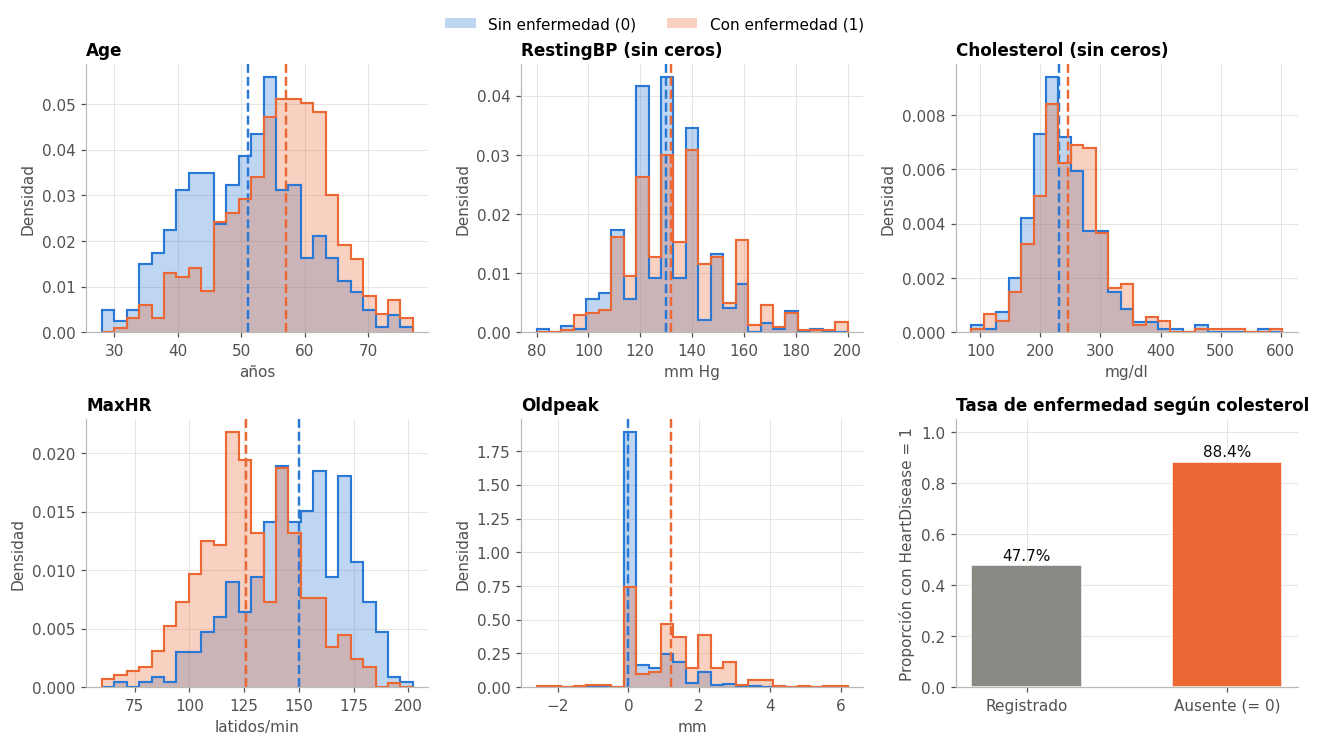

In [7]:
num_vars = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
unidades = {"Age": "años", "RestingBP": "mm Hg", "Cholesterol": "mg/dl", "MaxHR": "latidos/min", "Oldpeak": "mm"}
fig, axes = plt.subplots(2, 3, figsize=(12, 6.6))
for ax, var in zip(axes.flat, num_vars):
    datos = df[df[var] > 0] if var in mu.ZERO_AS_MISSING else df
    bins = np.histogram_bin_edges(datos[var], bins=25)
    for clase, color in [(0, mu.COLORS["neg"]), (1, mu.COLORS["pos"])]:
        valores = datos.loc[datos.HeartDisease == clase, var]
        ax.hist(valores, bins=bins, color=color, alpha=0.30, density=True, label=mu.CLASS_LABELS[clase])
        ax.hist(valores, bins=bins, color=color, histtype="step", lw=1.4, density=True)
        ax.axvline(datos.loc[datos.HeartDisease == clase, var].median(), color=color, lw=1.6, ls="--")
    nota = " (sin ceros)" if var in mu.ZERO_AS_MISSING else ""
    ax.set_title(f"{var}{nota}")
    ax.set_xlabel(unidades[var])
    ax.set_ylabel("Densidad")
ax = axes.flat[-1]
tasas = df.groupby(df["Cholesterol"] == 0)["HeartDisease"].mean()
ax.bar(["Registrado", "Ausente (= 0)"], [tasas[False], tasas[True]], color=[mu.COLORS["muted"], mu.COLORS["pos"]],
       width=0.55, edgecolor="white")
for i, v in enumerate([tasas[False], tasas[True]]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", color=mu.COLORS["ink"])
ax.set_ylim(0, 1.05)
ax.set_title("Tasa de enfermedad según colesterol")
ax.set_ylabel("Proporción con HeartDisease = 1")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.03))
fig.tight_layout()
mu.save_figure(fig, "fig01_numericas_por_clase")
plt.show()

**Figura 1.** Distribución de las variables numéricas por clase (histogramas normalizados; las líneas discontinuas marcan la mediana de cada clase). El último panel compara la prevalencia de enfermedad entre pacientes con y sin colesterol registrado.

Las variables con mayor desplazamiento entre clases son `MaxHR`, cuya mediana desciende de 150 a 126 latidos/min en los pacientes enfermos, y `Oldpeak`, que pasa de 0.0 a 1.2 mm. Ambos comportamientos tienen sustento fisiológico: la incompetencia cronotrópica y la depresión del ST durante el esfuerzo son marcadores clásicos de isquemia. La edad también se desplaza (51 frente a 57 años), mientras que la presión arterial y el colesterol, una vez descontados los ceros, muestran distribuciones casi superpuestas; su aporte directo es débil y, en el caso del colesterol, el contenido informativo reside sobre todo en su ausencia.

### 3.4 Variables categóricas y prevalencia de enfermedad

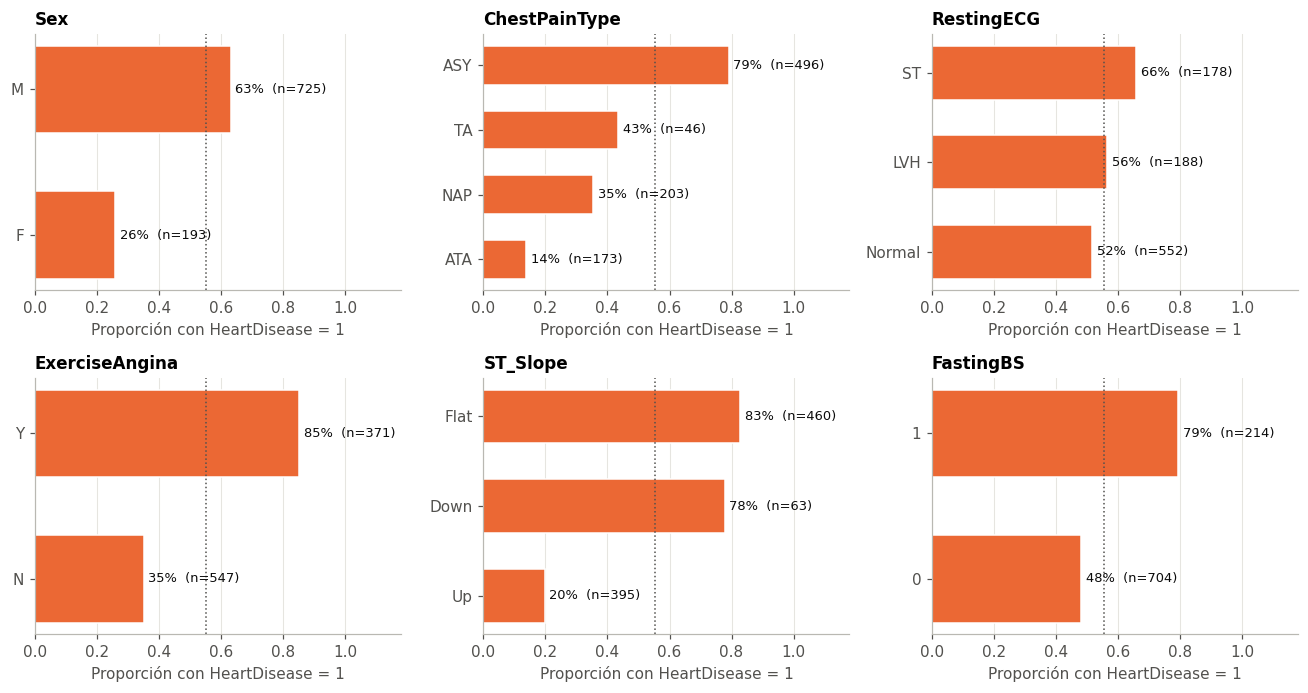

In [8]:
cat_vars = mu.CATEGORICAL + ["FastingBS"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.4))
prevalencia_global = df["HeartDisease"].mean()
for ax, var in zip(axes.flat, cat_vars):
    resumen = df.groupby(var)["HeartDisease"].agg(["mean", "size"]).sort_values("mean")
    y_pos = np.arange(len(resumen))
    ax.barh(y_pos, resumen["mean"], color=mu.COLORS["pos"], height=0.6, edgecolor="white")
    ax.set_yticks(y_pos, [str(i) for i in resumen.index])
    ax.axvline(prevalencia_global, color=mu.COLORS["ink2"], lw=1, ls=":")
    for yy, (m, n) in enumerate(zip(resumen["mean"], resumen["size"])):
        ax.text(m + 0.015, yy, f"{m:.0%}  (n={n})", va="center", fontsize=8.5, color=mu.COLORS["ink"])
    ax.set_xlim(0, 1.18)
    ax.set_title(var)
    ax.set_xlabel("Proporción con HeartDisease = 1")
    ax.grid(axis="y", visible=False)
fig.tight_layout()
mu.save_figure(fig, "fig02_categoricas_prevalencia")
plt.show()

**Figura 2.** Prevalencia de enfermedad por categoría; la línea punteada indica la prevalencia global (55.3 %) y entre paréntesis se reporta el tamaño de cada grupo.

Las categóricas concentran el mayor poder discriminante del conjunto. La pendiente del ST plana o descendente se asocia con prevalencias de 82.8 % y 77.8 %, frente a 19.7 % cuando es ascendente; la angina inducida por ejercicio eleva la prevalencia a 85.2 % (35.1 % en su ausencia) y el dolor torácico asintomático (ASY), contraintuitivamente, es la categoría de mayor riesgo (79.0 %), hecho bien documentado en isquemia silente. El sexo masculino (63.2 % frente a 25.9 %) y la glucemia elevada en ayunas (79.4 % frente a 48.0 %) completan el cuadro. `RestingECG`, en contraste, apenas se aparta de la prevalencia global. Ninguna categoría es rara en extremo (la menor, `ChestPainType = TA`, tiene 46 pacientes), lo que permite una codificación one-hot sin agrupar niveles.

### 3.5 Asociación entre variables numéricas

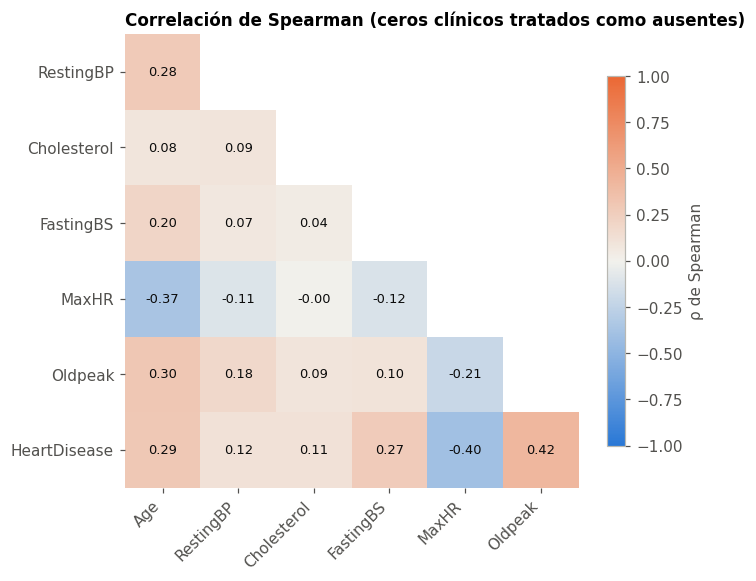

In [9]:
d = df.copy()
for col in mu.ZERO_AS_MISSING:
    d.loc[d[col] == 0, col] = np.nan
corr = d[["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak", "HeartDisease"]].corr("spearman")
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("div", [mu.COLORS["neg"], "#f2f1ec", mu.COLORS["pos"]])
fig, ax = plt.subplots(figsize=(6.6, 5.4))
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
im = ax.imshow(np.ma.masked_where(mask, corr), cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr) - 1), corr.columns[:-1], rotation=45, ha="right")
ax.set_yticks(range(1, len(corr)), corr.columns[1:])
ax.set_xlim(-0.5, len(corr) - 1.5)
ax.set_ylim(len(corr) - 0.5, 0.5)
for i in range(len(corr)):
    for j in range(i):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else mu.COLORS["ink"])
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="ρ de Spearman")
ax.set_title("Correlación de Spearman (ceros clínicos tratados como ausentes)")
fig.tight_layout()
mu.save_figure(fig, "fig03_correlacion_spearman")
plt.show()

**Figura 3.** Matriz de correlación de Spearman entre variables numéricas y el objetivo, calculada con eliminación por pares de los valores ausentes.

Las asociaciones con el objetivo confirman lo observado en la Figura 1: `Oldpeak` (ρ = 0.42), `MaxHR` (ρ = −0.40), `Age` (ρ = 0.29) y `FastingBS` (ρ = 0.27). Entre predictores, la correlación más alta es la de la edad con la frecuencia cardíaca máxima (ρ = −0.37), coherente con la disminución fisiológica de la reserva cronotrópica. Ningún par supera |ρ| = 0.4, por lo que no hay colinealidad que obligue a descartar variables, y la reducción de dimensionalidad (PCA) se evaluará solo como alternativa dentro del pipeline.

### 3.6 Síntesis del análisis exploratorio

El análisis deja cuatro decisiones de preprocesamiento: (i) los ceros de `Cholesterol` y `RestingBP` se recodifican como ausentes y se imputan con la mediana del conjunto de entrenamiento, acompañados de un indicador de ausencia; (ii) las variables continuas se escalan, requisito para los métodos basados en distancias o márgenes (k-NN, SVM, regresión logística regularizada); (iii) las cinco categóricas nominales se codifican con one-hot; y (iv) toda esta lógica debe ajustarse exclusivamente con datos de entrenamiento, dentro de un `Pipeline`, para que no viaje información del conjunto de evaluación al modelo.

## 4. Estrategia de preprocesamiento

El preprocesamiento se implementa como un `ColumnTransformer` con cuatro ramas, construido por la función `build_preprocessor` de `ml_utils.py`:

| Rama | Columnas | Transformación |
|---|---|---|
| `zero_missing` | `RestingBP`, `Cholesterol` | `SimpleImputer(missing_values=0, strategy="median", add_indicator=True)` → `MinMaxScaler` |
| `num` | `Age`, `MaxHR`, `Oldpeak` | `MinMaxScaler` |
| `bin` | `FastingBS` | sin transformación (ya está en {0, 1}) |
| `cat` | `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope` | `OneHotEncoder(drop="if_binary", handle_unknown="ignore")` |

Se conserva el `MinMaxScaler` del enunciado. La codificación one-hot elimina una columna solo en las variables binarias (`Sex`, `ExerciseAngina`), lo que evita la redundancia perfecta sin sacrificar la interpretabilidad de los niveles en las multinomiales; los modelos lineales se usan con regularización, que resuelve la colinealidad residual. La opción `handle_unknown="ignore"` garantiza que una categoría no vista durante el ajuste no detenga la API de inferencia. Usar `SimpleImputer` con `missing_values=0` en lugar de una función propia mantiene el modelo serializado libre de código ajeno a scikit-learn, condición necesaria para cargarlo dentro del contenedor Docker.

In [10]:
print(inspect.getsource(mu.build_preprocessor))

def build_preprocessor(scaler=None) -> ColumnTransformer:
    """Construye el ``ColumnTransformer`` de preprocesamiento.

    * ``RestingBP`` y ``Cholesterol``: el valor 0 se trata como faltante, se
      imputa con la mediana del entrenamiento y se añade un indicador binario
      de ausencia, porque el patrón de ausencia es informativo.
    * Numéricas continuas: escalado (``MinMaxScaler`` por defecto, como en el
      enunciado; puede sustituirse con el argumento ``scaler``).
    * Categóricas nominales: codificación one-hot; ``drop='if_binary'`` evita
      la trampa de la variable ficticia en las binarias y
      ``handle_unknown='ignore'`` protege la inferencia ante categorías nuevas.
    """
    scaler = scaler if scaler is not None else MinMaxScaler()
    zero_missing = Pipeline([
        ("imputer", SimpleImputer(missing_values=0, strategy="median",
                                  add_indicator=True)),
        ("scaler", scaler),
    ])
    numeric = Pipeline([("scaler", sca

In [11]:
X_train, X_test, y_train, y_test = mu.split_data(df)
prep = mu.build_preprocessor().fit(X_train)
nombres = prep.get_feature_names_out()
print(f"Entrenamiento: {X_train.shape}, prueba: {X_test.shape}")
print(f"Prevalencia — entrenamiento: {y_train.mean():.3f}, prueba: {y_test.mean():.3f}")
print(f"Variables tras el preprocesamiento ({len(nombres)}):")
print(list(nombres))

Entrenamiento: (734, 11), prueba: (184, 11)
Prevalencia — entrenamiento: 0.553, prueba: 0.554
Variables tras el preprocesamiento (19):
['zero_missing__RestingBP', 'zero_missing__Cholesterol', 'zero_missing__missingindicator_Cholesterol', 'num__Age', 'num__MaxHR', 'num__Oldpeak', 'bin__FastingBS', 'cat__Sex_M', 'cat__ChestPainType_ASY', 'cat__ChestPainType_ATA', 'cat__ChestPainType_NAP', 'cat__ChestPainType_TA', 'cat__RestingECG_LVH', 'cat__RestingECG_Normal', 'cat__RestingECG_ST', 'cat__ExerciseAngina_Y', 'cat__ST_Slope_Down', 'cat__ST_Slope_Flat', 'cat__ST_Slope_Up']


La partición estratificada conserva la prevalencia (0.553 en entrenamiento y 0.554 en prueba, sobre 734 y 184 pacientes). El preprocesador produce 19 columnas. Conviene notar que solo se genera indicador de ausencia para `Cholesterol`: el único cero de `RestingBP` quedó en el conjunto de prueba, de modo que el imputador ajustado con entrenamiento no observó faltantes en esa columna. Si ese valor llega a inferencia, se imputará igualmente con la mediana de entrenamiento; este es precisamente el comportamiento correcto de un transformador ajustado sin mirar la prueba.

## 5. Fuga de datos: demostración y diagnóstico

La fuga de datos ocurre cuando el proceso de entrenamiento accede, directa o indirectamente, a información que no estaría disponible al momento de predecir. Conviene distinguir dos mecanismos: la **fuga de objetivo**, en la que un predictor codifica el desenlace (por ejemplo, una variable registrada después del diagnóstico), y la **fuga de preprocesamiento o de validación**, en la que un paso aprendido (escalado, imputación, selección de variables) se ajusta con datos que luego se usan para evaluar. Los experimentos siguientes ilustran ambos.

### 5.1 Réplica del experimento propuesto en el enunciado

Se reproduce el código del enunciado con dos adaptaciones mínimas impuestas por el conjunto de Kaggle: el objetivo se llama `HeartDisease` (no `target`) y las cinco variables categóricas se convierten a indicadoras con `pd.get_dummies` para que `MinMaxScaler` y `SVC` puedan operar sobre una matriz numérica, como en el ejemplo original.

In [12]:
# Datos en formato numérico, como en el ejemplo del enunciado
X = pd.get_dummies(df.drop("HeartDisease", axis=1), drop_first=True, dtype=float)
y = df["HeartDisease"]

# Variable artificial que introduce fuga
np.random.seed(0)
X["leaky_feature"] = y + np.random.normal(0, 0.01, size=len(y))


def demo_enunciado(X, y):
    # Ejemplo con fuga de datos (data leakage)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    grid_l = GridSearchCV(SVC(probability=True), param_grid={"C": [0.1, 1, 10], "gamma": [0.01, 0.1]},
                          cv=5, scoring="roc_auc")
    grid_l.fit(X_train_l, y_train_l)
    auc_l = roc_auc_score(y_test_l, grid_l.predict_proba(X_test_l)[:, 1])

    # Flujo correcto (sin fuga)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    pipe = Pipeline([("scaler", MinMaxScaler()), ("svc", SVC(probability=True))])
    param_grid = {"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1]}
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc")
    grid.fit(X_train, y_train)
    auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
    return auc_l, auc


auc_l, auc = demo_enunciado(X, y)
print(f"AUC con fuga: {auc_l:.3f}")
print(f"AUC sin fuga: {auc:.3f}")

AUC con fuga: 1.000
AUC sin fuga: 1.000


Ambos flujos alcanzan un AUC de 1.000. El resultado es instructivo precisamente porque contradice la intuición de que el `Pipeline` «corrige» la fuga: `leaky_feature` se construyó como el objetivo más un ruido de desviación 0.01, de modo que está presente en entrenamiento y en prueba y separa las clases sin error. Encapsular el escalado protege contra la fuga de preprocesamiento, pero no puede detectar que un predictor contenga la respuesta. Esa responsabilidad corresponde a la auditoría de variables, que se aborda a continuación.

### 5.2 Detección de fuga de objetivo mediante auditoría univariada

Un procedimiento simple y efectivo consiste en calcular, sobre el conjunto de entrenamiento, el AUC de cada predictor tomado aisladamente. En problemas clínicos reales es excepcional que una sola variable discrimine casi a la perfección; un AUC univariado mayor que 0.95 (o menor que 0.05) se trata como alerta. La función `univariate_auc_audit` implementa esta regla (las categóricas se representan por la tasa de positivos de su nivel).

In [13]:
X_aud = df[mu.FEATURES].copy()
X_aud["leaky_feature"] = X["leaky_feature"]
X_aud_train, _, y_aud_train, _ = train_test_split(X_aud, y, test_size=0.2, stratify=y, random_state=42)
auditoria = mu.univariate_auc_audit(X_aud_train, y_aud_train)
auditoria

,Variable,AUC univariado,Poder discriminante |AUC-0.5|,Sospecha de fuga
0,leaky_feature,1.000,0.500,Sí
1,ST_Slope,0.823,0.323,No
2,ChestPainType,0.784,0.284,No
3,ExerciseAngina,0.743,0.243,No
4,MaxHR,0.262,0.238,No
5,Oldpeak,0.719,0.219,No
6,Age,0.648,0.148,No
7,Sex,0.615,0.115,No
8,FastingBS,0.610,0.110,No
9,Cholesterol,0.417,0.083,No


La auditoría aísla `leaky_feature` con AUC = 1.000, mientras que el predictor legítimo más fuerte, `ST_Slope`, se queda en torno a 0.82, y ninguna otra variable supera 0.80. La variable se elimina y el experimento del enunciado se repite sobre los once predictores originales.

In [14]:
auc_l_limpio, auc_limpio = demo_enunciado(X.drop(columns="leaky_feature"), y)
print(f"AUC con fuga de preprocesamiento: {auc_l_limpio:.4f}")
print(f"AUC sin fuga (Pipeline):          {auc_limpio:.4f}")

AUC con fuga de preprocesamiento: 0.9215
AUC sin fuga (Pipeline):          0.9215


### 5.3 Magnitud de la fuga de preprocesamiento en este conjunto

Sin la variable artificial, los dos flujos del enunciado producen el mismo AUC hasta la cuarta cifra decimal (0.9215). La explicación es casi determinista y conviene verificarla: `MinMaxScaler` solo aprende el mínimo y el máximo de cada columna, de manera que, si los extremos de la muestra completa caen en la partición de entrenamiento, el escalador ajustado con todos los datos coincide con el ajustado solo con entrenamiento.

In [15]:
Xn = X.drop(columns="leaky_feature")
Xn_train, Xn_test = train_test_split(Xn, test_size=0.2, random_state=42)
s_total = MinMaxScaler().fit(Xn)
s_train = MinMaxScaler().fit(Xn_train)
coinciden = np.isclose(s_total.data_min_, s_train.data_min_) & np.isclose(s_total.data_max_, s_train.data_max_)
print(f"Columnas con mínimo y máximo idénticos (total vs. entrenamiento): {coinciden.sum()} de {len(coinciden)}")
print("Columnas que difieren:", list(Xn.columns[~coinciden]))

Columnas con mínimo y máximo idénticos (total vs. entrenamiento): 14 de 15
Columnas que difieren: ['Age']


Con esa semilla, 14 de las 15 columnas tienen extremos idénticos en ambos ajustes; solo difiere `Age`, cuyo rango cambia en uno de sus bordes. El efecto es un reescalado afín marginal de una sola variable, insuficiente para alterar el ordenamiento de las probabilidades en prueba, que es lo único que mide el AUC. Para cuantificar el sesgo en condiciones generales se repite el experimento sobre 50 particiones aleatorias distintas, comparando el preprocesamiento completo del proyecto (imputación con indicador, escalado y one-hot) ajustado sobre todos los datos antes de partir, frente al mismo preprocesamiento ajustado dentro del `Pipeline`. Se usa una regresión logística para que la comparación aísle el efecto del preprocesamiento y no la búsqueda de hiperparámetros.

In [16]:
def auc_preprocesamiento(seed, dentro_del_pipeline):
    Xtr, Xte, ytr, yte = train_test_split(df[mu.FEATURES], df["HeartDisease"], test_size=0.2,
                                          stratify=df["HeartDisease"], random_state=seed)
    clf = LogisticRegression(max_iter=5000)
    if dentro_del_pipeline:
        modelo = Pipeline([("prep", mu.build_preprocessor()), ("clf", clf)]).fit(Xtr, ytr)
        proba = modelo.predict_proba(Xte)[:, 1]
    else:
        prep_total = mu.build_preprocessor().fit(df[mu.FEATURES])   # ajuste con TODOS los datos
        clf.fit(prep_total.transform(Xtr), ytr)
        proba = clf.predict_proba(prep_total.transform(Xte))[:, 1]
    return roc_auc_score(yte, proba)


semillas = range(50)
rep = pd.DataFrame({
    "Con fuga": [auc_preprocesamiento(s, False) for s in semillas],
    "Sin fuga": [auc_preprocesamiento(s, True) for s in semillas],
})
rep["Diferencia"] = rep["Con fuga"] - rep["Sin fuga"]
rep.describe().loc[["mean", "std", "min", "max"]]

,Con fuga,Sin fuga,Diferencia
mean,0.926,0.926,-6.456e-05
std,0.015,0.015,3.105e-04
min,0.882,0.882,-9.565e-04
max,0.961,0.960,7.174e-04


In [17]:
print(f"Particiones en que el flujo con fuga obtiene mayor AUC: {(rep['Diferencia'] > 0).sum()} de {len(rep)}")
print(f"Particiones con diferencia nula: {(rep['Diferencia'].abs() < 1e-12).sum()}")
print(f"Diferencia media: {rep['Diferencia'].mean():+.5f}  (máxima absoluta {rep['Diferencia'].abs().max():.5f})")

Particiones en que el flujo con fuga obtiene mayor AUC: 17 de 50
Particiones con diferencia nula: 14
Diferencia media: -0.00006  (máxima absoluta 0.00096)


En las 50 particiones el AUC medio es 0.926 en ambos flujos; la diferencia media es −0.00006 y la máxima en valor absoluto no llega a 0.001, con 14 particiones de diferencia exactamente nula y solo 17 de 50 en que el flujo contaminado obtiene ventaja. En este conjunto, por tanto, ajustar imputación, escalado y codificación con todos los datos no infla de manera apreciable la estimación del desempeño. El hallazgo no contradice la teoría, la precisa: las transformaciones no supervisadas (mínimos, máximos, medianas, categorías) varían poco entre la muestra completa y una submuestra del 80 % cuando el tamaño muestral es moderado, de modo que la información filtrada es casi nula. El riesgo real aparece cuando el paso de preprocesamiento usa la variable respuesta, cuando el conjunto es pequeño frente a la dimensión o cuando existen valores extremos que solo aparecen en prueba. Mantener todo dentro del `Pipeline` sigue siendo obligatorio, porque es la única garantía de que el procedimiento evaluado sea idéntico al que se desplegará.

### 5.4 Caso crítico: selección de variables antes de la validación cruzada

El experimento anterior muestra que la fuga es grave cuando el paso de preprocesamiento usa la variable respuesta. La selección univariada de variables es el ejemplo canónico (sección 10.4 del curso). Para hacerlo evidente se construye un problema **sin señal alguna**: se agregan 2 000 variables de ruido gaussiano a los predictores y se permutan aleatoriamente las etiquetas, de modo que ningún modelo honesto puede superar un AUC de 0.5. Luego se seleccionan las 20 variables más asociadas con la respuesta mediante `SelectKBest(f_classif)`, primero sobre todos los datos y después dentro de un `Pipeline`, y se estima el AUC con validación cruzada estratificada de cinco pliegues.

In [18]:
rng = np.random.default_rng(mu.RANDOM_STATE)
X_ruido = np.hstack([Xn.to_numpy(), rng.normal(size=(len(Xn), 2000))])
y_perm = rng.permutation(y.to_numpy())          # se rompe toda relación X–y
cv = mu.make_cv()
logit = LogisticRegression(max_iter=2000)

# Con fuga: la selección «ve» las etiquetas de los pliegues de validación
selector = SelectKBest(f_classif, k=20).fit(X_ruido, y_perm)
auc_sel_fuga = cross_val_score(logit, selector.transform(X_ruido), y_perm, cv=cv, scoring="roc_auc")

# Sin fuga: la selección se reajusta en cada pliegue con datos de entrenamiento
pipe_sel = Pipeline([("select", SelectKBest(f_classif, k=20)), ("clf", logit)])
auc_sel_ok = cross_val_score(pipe_sel, X_ruido, y_perm, cv=cv, scoring="roc_auc")

print(f"AUC-CV con selección previa (fuga): {auc_sel_fuga.mean():.3f} ± {auc_sel_fuga.std():.3f}")
print(f"AUC-CV con selección en el Pipeline: {auc_sel_ok.mean():.3f} ± {auc_sel_ok.std():.3f}")

AUC-CV con selección previa (fuga): 0.707 ± 0.023
AUC-CV con selección en el Pipeline: 0.521 ± 0.035


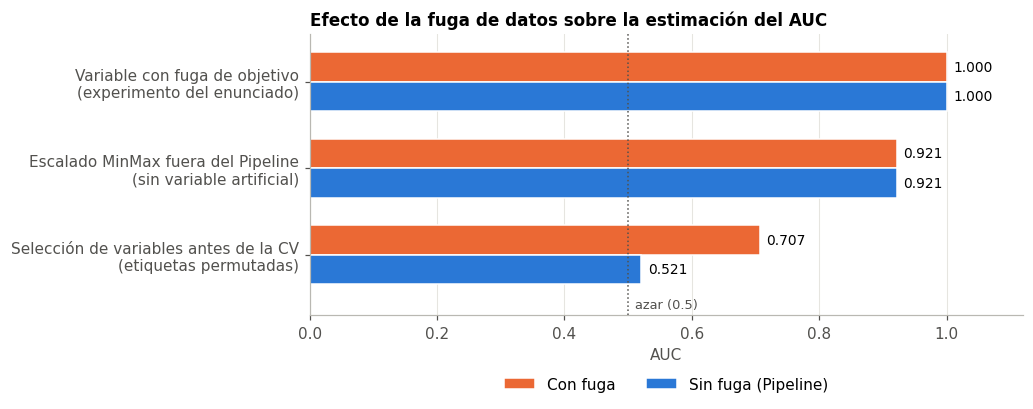

In [19]:
escenarios = pd.DataFrame({
    "Escenario": ["Variable con fuga de objetivo\n(experimento del enunciado)",
                  "Escalado MinMax fuera del Pipeline\n(sin variable artificial)",
                  "Selección de variables antes de la CV\n(etiquetas permutadas)"],
    "Con fuga": [auc_l, auc_l_limpio, auc_sel_fuga.mean()],
    "Sin fuga": [auc, auc_limpio, auc_sel_ok.mean()],
})
fig, ax = plt.subplots(figsize=(9.5, 3.9))
yy = np.arange(len(escenarios))[::-1]
h = 0.34
ax.barh(yy + h / 2, escenarios["Con fuga"], height=h, color=mu.COLORS["pos"], label="Con fuga", edgecolor="white")
ax.barh(yy - h / 2, escenarios["Sin fuga"], height=h, color=mu.COLORS["neg"], label="Sin fuga (Pipeline)", edgecolor="white")
for y0, a, b in zip(yy, escenarios["Con fuga"], escenarios["Sin fuga"]):
    ax.text(a + 0.01, y0 + h / 2, f"{a:.3f}", va="center", fontsize=9)
    ax.text(b + 0.01, y0 - h / 2, f"{b:.3f}", va="center", fontsize=9)
ax.axvline(0.5, color=mu.COLORS["ink2"], ls=":", lw=1)
ax.text(0.51, -0.62, "azar (0.5)", fontsize=8.5, color=mu.COLORS["ink2"])
ax.set_yticks(yy, escenarios["Escenario"])
ax.set_xlim(0, 1.12)
ax.set_xlabel("AUC")
ax.grid(axis="y", visible=False)
ax.set_ylim(-0.7, yy.max() + 0.55)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2)
ax.set_title("Efecto de la fuga de datos sobre la estimación del AUC")
fig.tight_layout()
mu.save_figure(fig, "fig04_escenarios_fuga")
plt.show()

**Figura 4.** AUC estimado con y sin fuga en los tres escenarios analizados. La línea punteada marca el desempeño de un clasificador aleatorio.

El tercer escenario es el más elocuente. Con etiquetas permutadas no existe señal que aprender, y el procedimiento correcto lo reconoce: el AUC del `Pipeline` es 0.521 ± 0.035, indistinguible del azar. La selección previa a la validación cruzada, en cambio, reporta 0.707 ± 0.023, un desempeño aparentemente moderado que es enteramente ficticio: entre 2 000 variables de ruido, las 20 elegidas son justamente las que por azar se correlacionan con las etiquetas de toda la muestra, incluidas las de los pliegues de validación. Es el sesgo de selección descrito por Ambroise y McLachlan (2002) en genómica. Leídos en conjunto, los tres experimentos establecen la jerarquía de riesgos que guía el resto del proyecto: la fuga de objetivo se combate auditando variables, la fuga de preprocesamiento supervisado se combate con `Pipeline`, y la de preprocesamiento no supervisado, aunque aquí resulta despreciable, se elimina por la misma vía sin costo adicional.

## 6. Comparación de clasificadores sin fuga

### 6.1 Diseño experimental y funciones reutilizables

Siguiendo el enunciado, cada modelo se implementa dentro de un `Pipeline` cuyo primer paso es el preprocesador de la sección 4, se optimiza con `GridSearchCV` (validación cruzada estratificada de cinco pliegues, criterio de reajuste: AUC) y se evalúa una única vez en el conjunto de prueba. Se incluyen los nueve clasificadores estudiados en el curso hasta este capítulo: k-NN (cap. 2), regresión logística con penalización L1 o L2 (cap. 3, análogos de clasificación de Lasso y Ridge), Naive Bayes gaussiano (cap. 4), árbol de decisión, Random Forest, Gradient Boosting y XGBoost (cap. 5), SVM con núcleo RBF (cap. 6) y la combinación PCA + SVM (caps. 7 y 10.5). La lógica de entrenamiento y evaluación está encapsulada en funciones:

In [20]:
for funcion in (mu.train_pipeline, mu.evaluate_model, mu.run_benchmark):
    print(inspect.getsource(funcion))

def train_pipeline(X_train, y_train, model, param_grid, preprocessor=None,
                   cv=None, scoring="roc_auc", extra_steps=None) -> GridSearchCV:
    """Entrena ``preprocesamiento -> [pasos extra] -> clasificador`` con GridSearchCV.

    Toda transformación se ajusta dentro de cada pliegue, de modo que la
    información de validación nunca participa en el ajuste del preprocesador.
    """
    steps = [("prep", preprocessor if preprocessor is not None else build_preprocessor())]
    steps += list(extra_steps or [])
    steps.append(("clf", model))
    grid = GridSearchCV(
        Pipeline(steps), param_grid=param_grid, cv=cv or make_cv(),
        scoring={"roc_auc": "roc_auc", "accuracy": "accuracy"}, refit=scoring,
        n_jobs=-1, return_train_score=True,
    )
    grid.fit(X_train, y_train)
    return grid

def evaluate_model(estimator, X_test, y_test, threshold: float = 0.5) -> dict:
    """AUC y exactitud en el conjunto de prueba."""
    proba = estimator.predict_prob

In [21]:
modelos = mu.candidate_models()
espacio = pd.DataFrame([
    {"Modelo": nombre,
     "Hiperparámetros explorados": "; ".join(f"{k.split('__')[1]} ∈ {list(v) if len(v) <= 7 else f'{{{v[0]}, …, {v[-1]}}} ({len(v)} valores)'}"
                                             for k, v in spec["grid"].items()),
     "Combinaciones": int(np.prod([len(v) for v in spec["grid"].values()]))}
    for nombre, spec in modelos.items()
]).set_index("Modelo")
with pd.option_context("display.max_colwidth", None):
    display(espacio)
print(f"Total de ajustes (combinaciones × 5 pliegues): {espacio['Combinaciones'].sum() * 5:,}")

,Hiperparámetros explorados,Combinaciones
Modelo,,
SVC (RBF),"C ∈ [0.01, 0.1, 1, 10, 100]; gamma ∈ ['scale', 0.001, 0.01, 0.1, 1]",25
Regresión logística,"C ∈ [0.001, 0.01, 0.1, 1, 10, 100]; penalty ∈ ['l1', 'l2']",12
k-NN,"n_neighbors ∈ {3, …, 81} (40 valores); weights ∈ ['uniform', 'distance']; p ∈ [1, 2]",160
Naive Bayes gaussiano,"var_smoothing ∈ {1e-09, …, 10.0} (11 valores)",11
Árbol de decisión,"max_depth ∈ [2, 3, 4, 5, 6, 8, None]; min_samples_leaf ∈ [1, 5, 10, 20, 40]; criterion ∈ ['gini', 'entropy']",70
Random Forest,"max_depth ∈ [None, 4, 6, 8]; max_features ∈ ['sqrt', 0.5]; min_samples_leaf ∈ [1, 3, 5, 10]",32
Gradient Boosting,"n_estimators ∈ [50, 100, 200, 400]; learning_rate ∈ [0.01, 0.05, 0.1]; max_depth ∈ [1, 2, 3]; subsample ∈ [0.8, 1.0]",72
XGBoost,"n_estimators ∈ [100, 300, 600]; learning_rate ∈ [0.005, 0.01, 0.05, 0.1]; max_depth ∈ [2, 3, 4]; subsample ∈ [0.8, 1.0]; colsample_bytree ∈ [0.5, 0.7, 1.0]",216
PCA + SVC (RBF),"n_components ∈ [2, 4, 6, 8, 10, 12]; C ∈ [0.1, 1, 10]; gamma ∈ ['scale', 0.01, 0.1]",54


Total de ajustes (combinaciones × 5 pliegues): 3,260


**Tabla 2.** Espacio de búsqueda por modelo. Las rejillas se ampliaron hasta que ningún óptimo quedara en el borde explorado, salvo donde el borde es el valor natural (por ejemplo, `max_depth = None`).

### 6.2 Resultados y ranking comparativo

In [22]:
ranking, ajustados = mu.run_benchmark(modelos, X_train, y_train, X_test, y_test)
cols_fmt = {c: "{:.3f}" for c in ["AUC CV (media)", "AUC CV (d.e.)", "Accuracy CV", "AUC entrenamiento",
                                  "AUC prueba", "Accuracy prueba"]}
cols_fmt["Tiempo (s)"] = "{:.1f}"
(ranking.style.format(cols_fmt)
        .background_gradient(subset=["AUC CV (media)", "AUC prueba", "Accuracy prueba"], cmap="Oranges")
        .set_caption("Tabla 3. Ranking de clasificadores ordenado por AUC de validación cruzada"))

,Modelo,AUC CV (media),AUC CV (d.e.),Accuracy CV,AUC entrenamiento,AUC prueba,IC95% AUC prueba,Accuracy prueba,Combinaciones,Tiempo (s)
Ranking,,,,,,,,,,
1,XGBoost,0.939,0.024,0.866,0.986,0.935,"[0.895, 0.969]",0.897,216,53.1
2,Random Forest,0.934,0.026,0.861,0.975,0.930,"[0.887, 0.965]",0.880,32,39.5
3,Gradient Boosting,0.934,0.022,0.858,0.967,0.932,"[0.889, 0.967]",0.908,72,46.5
4,k-NN,0.930,0.032,0.860,1.000,0.939,"[0.899, 0.972]",0.908,160,25.0
5,PCA + SVC (RBF),0.929,0.035,0.862,0.938,0.934,"[0.894, 0.967]",0.875,54,11.2
6,Regresión logística,0.929,0.037,0.854,0.936,0.927,"[0.884, 0.963]",0.880,12,1.3
7,Naive Bayes gaussiano,0.928,0.035,0.862,0.930,0.927,"[0.884, 0.963]",0.886,11,1.1
8,SVC (RBF),0.928,0.036,0.860,0.941,0.935,"[0.894, 0.968]",0.880,25,14.7
9,Árbol de decisión,0.910,0.028,0.838,0.934,0.887,"[0.835, 0.930]",0.777,70,9.1


In [23]:
mejores = pd.DataFrame({n: g.best_params_ for n, g in ajustados.items()}).T
mejores.columns = [c.split("__")[1] for c in mejores.columns]
mejores.fillna("—")

,C,gamma,penalty,n_neighbors,p,weights,var_smoothing,criterion,max_depth,min_samples_leaf,max_features,learning_rate,n_estimators,subsample,colsample_bytree,n_components
SVC (RBF),1.0,0.1,—,—,—,—,—,—,—,—,—,—,—,—,—,—
Regresión logística,1,—,l2,—,—,—,—,—,—,—,—,—,—,—,—,—
k-NN,—,—,—,53,2,distance,—,—,—,—,—,—,—,—,—,—
Naive Bayes gaussiano,—,—,—,—,—,—,1.0,—,—,—,—,—,—,—,—,—
Árbol de decisión,—,—,—,—,—,—,—,gini,4,20,—,—,—,—,—,—
Random Forest,—,—,—,—,—,—,—,—,—,5,sqrt,—,—,—,—,—
Gradient Boosting,—,—,—,—,—,—,—,—,3.0,—,—,0.05,50.0,0.8,—,—
XGBoost,—,—,—,—,—,—,—,—,4.0,—,—,0.05,100.0,1.0,0.5,—
PCA + SVC (RBF),1.0,0.1,—,—,—,—,—,—,—,—,—,—,—,—,—,10.0


**Tabla 4.** Hiperparámetros óptimos seleccionados por `GridSearchCV`.

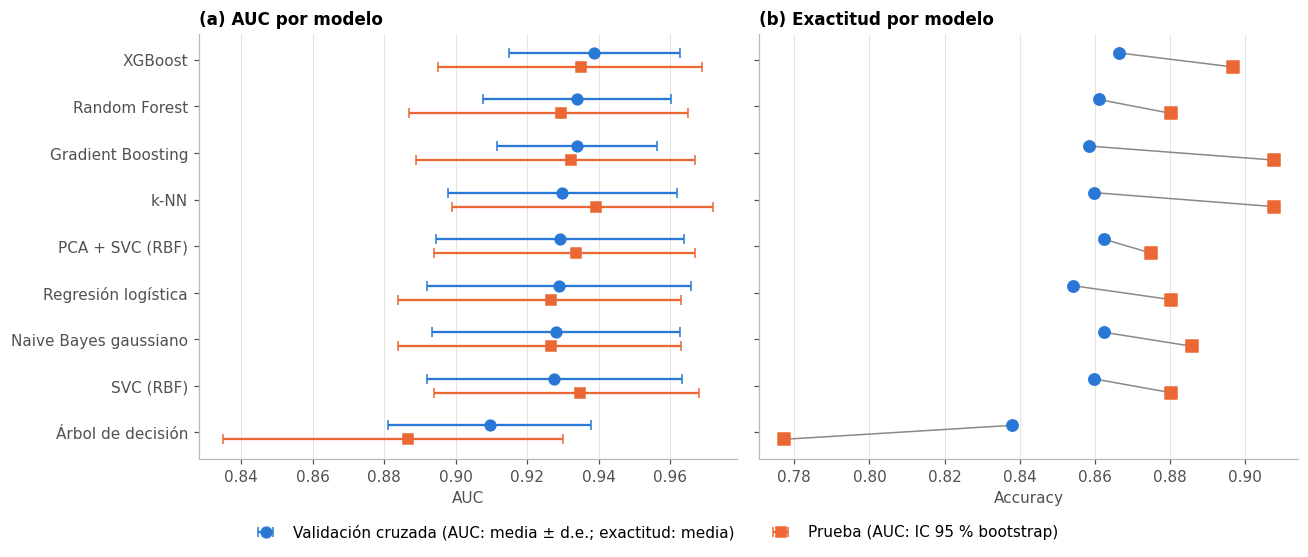

In [24]:
r = ranking.iloc[::-1].reset_index()
ic = r["IC95% AUC prueba"].str.strip("[]").str.split(", ", expand=True).astype(float)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
yy = np.arange(len(r))
ax = axes[0]
ax.errorbar(r["AUC CV (media)"], yy + 0.15, xerr=r["AUC CV (d.e.)"], fmt="o", color=mu.COLORS["neg"],
            ms=7, capsize=3, lw=1.5, label="Validación cruzada (media ± d.e.)")
ax.errorbar(r["AUC prueba"], yy - 0.15, xerr=[r["AUC prueba"] - ic[0], ic[1] - r["AUC prueba"]], fmt="s",
            color=mu.COLORS["pos"], ms=7, capsize=3, lw=1.5, label="Prueba (IC 95 % bootstrap)")
ax.set_yticks(yy, r["Modelo"])
ax.set_xlabel("AUC")
ax.set_title("(a) AUC por modelo")
ax.grid(axis="y", visible=False)
ax = axes[1]
ax.scatter(r["Accuracy CV"], yy + 0.15, marker="o", s=55, color=mu.COLORS["neg"], label="Validación cruzada", zorder=3)
ax.scatter(r["Accuracy prueba"], yy - 0.15, marker="s", s=55, color=mu.COLORS["pos"], label="Prueba", zorder=3)
for y0, a, b in zip(yy, r["Accuracy CV"], r["Accuracy prueba"]):
    ax.plot([a, b], [y0 + 0.15, y0 - 0.15], color=mu.COLORS["muted"], lw=1, zorder=2)
ax.set_xlabel("Accuracy")
ax.set_title("(b) Exactitud por modelo")
ax.grid(axis="y", visible=False)
h1, l1 = axes[0].get_legend_handles_labels()
fig.legend(h1, ["Validación cruzada (AUC: media ± d.e.; exactitud: media)", "Prueba (AUC: IC 95 % bootstrap)"],
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout()
mu.save_figure(fig, "fig05_ranking_modelos")
plt.show()

**Figura 5.** Desempeño de los nueve clasificadores optimizados, ordenados de arriba abajo por AUC de validación cruzada. (a) AUC en validación cruzada con su desviación estándar entre pliegues y AUC en prueba con intervalo de confianza bootstrap al 95 % (2 000 remuestreos). (b) Exactitud en validación cruzada y en prueba.

Ocho de los nueve clasificadores se concentran en una franja estrecha de AUC de validación cruzada, entre 0.928 (SVC) y 0.939 (XGBoost), con desviaciones entre pliegues de 0.022 a 0.037. El árbol de decisión individual queda claramente rezagado (AUC-CV de 0.910; AUC de prueba de 0.887 y exactitud de 0.777), resultado esperable de un estimador de alta varianza cuya configuración óptima (4 niveles, hojas de al menos 20 pacientes) limita su capacidad para representar fronteras suaves. XGBoost encabeza el ranking por AUC de validación cruzada y en prueba obtiene AUC = 0.935 con exactitud de 0.897; Gradient Boosting y k-NN logran las exactitudes de prueba más altas (0.908).

Dos precauciones gobiernan la lectura de la tabla. En primer lugar, los intervalos de confianza bootstrap del AUC de prueba tienen una amplitud cercana a 0.07 y se solapan casi por completo entre los ocho mejores modelos; con 184 pacientes de prueba, ninguna de esas diferencias es estadísticamente distinguible. Por ello el ranking se ordena por el AUC de validación cruzada, estimado sobre 734 pacientes y cinco particiones, y no por el desempeño en prueba, que se reserva como verificación final y no como criterio de selección: escoger el modelo con mejor AUC de prueba equivaldría a una forma sutil de fuga. En segundo lugar, la brecha entre el AUC de entrenamiento y el de validación orienta sobre el sobreajuste: es pequeña en los modelos lineales, Naive Bayes y SVC (alrededor de 0.01), moderada en los métodos de ensamble (0.03 a 0.05) y máxima en k-NN, cuyo AUC de entrenamiento de 1.000 es un artefacto de la ponderación por distancia (en entrenamiento cada punto es su propio vecino a distancia cero) y no una señal de memorización perjudicial, como confirma su AUC de prueba de 0.939.

### 6.3 Comparación con el SVC de referencia

El enunciado pide contrastar los clasificadores adicionales con el SVC. La tabla siguiente expresa cada modelo como diferencia respecto del SVC con núcleo RBF.

In [25]:
ref = ranking.set_index("Modelo").loc["SVC (RBF)"]
contraste = ranking.set_index("Modelo")[["AUC CV (media)", "AUC prueba", "Accuracy prueba"]].sub(
    ref[["AUC CV (media)", "AUC prueba", "Accuracy prueba"]].astype(float))
contraste.columns = ["Δ AUC CV vs. SVC", "Δ AUC prueba vs. SVC", "Δ Accuracy prueba vs. SVC"]
contraste.style.format("{:+.3f}").set_caption("Tabla 5. Diferencias respecto del SVC (RBF)")

,Δ AUC CV vs. SVC,Δ AUC prueba vs. SVC,Δ Accuracy prueba vs. SVC
Modelo,,,
XGBoost,+0.011,+0.000,+0.016
Random Forest,+0.007,-0.005,+0.000
Gradient Boosting,+0.006,-0.003,+0.027
k-NN,+0.002,+0.005,+0.027
PCA + SVC (RBF),+0.002,-0.001,-0.005
Regresión logística,+0.001,-0.008,+0.000
Naive Bayes gaussiano,+0.001,-0.008,+0.005
SVC (RBF),+0.000,+0.000,+0.000
Árbol de decisión,-0.018,-0.048,-0.103


Frente al SVC con núcleo RBF, todos los modelos salvo el árbol de decisión mejoran el AUC de validación cruzada, pero por márgenes de entre +0.001 (regresión logística y Naive Bayes) y +0.011 (XGBoost), con Random Forest (+0.007) y Gradient Boosting (+0.006) en posición intermedia; en ningún caso la ganancia supera la desviación estándar entre pliegues. En el conjunto de prueba las diferencias de AUC respecto del SVC son de pocas milésimas para los ocho mejores modelos, mientras que las de exactitud alcanzan casi tres puntos porcentuales, porque esta métrica depende del umbral de 0.5 y es mucho más sensible que el AUC a los pocos pacientes cercanos a la frontera de decisión. La conclusión práctica es que, una vez resuelto el preprocesamiento sin fuga, la representación de los datos condiciona el desempeño más que la elección del algoritmo. Los métodos de *boosting* ofrecen la mejor estimación central y serán candidatos naturales en la Etapa 2, donde la selección del modelo final se hará con una búsqueda conjunta sobre familias de modelos dentro de un único `GridSearchCV`.

## 7. Conclusiones

El análisis exploratorio mostró que el conjunto *Heart Failure Prediction* no tiene faltantes explícitos, pero sí 172 valores de colesterol codificados como cero, cuyo patrón de ausencia se asocia con una prevalencia de enfermedad del 88.4 %. Esa observación motivó un preprocesamiento que imputa con la mediana de entrenamiento y conserva un indicador de ausencia, encapsulado junto con el escalado MinMax y la codificación one-hot en un `ColumnTransformer`.

La demostración de fuga de datos permitió separar tres mecanismos. La variable artificial del enunciado produce un AUC de 1.000 incluso dentro de un `Pipeline`, lo que prueba que la encapsulación no sustituye a la auditoría de variables; una regla de AUC univariado superior a 0.95 la identifica sin ambigüedad. El preprocesamiento no supervisado ajustado con todos los datos introdujo, en 50 particiones, un sesgo medio inferior a 10⁻⁴ en el AUC, despreciable en este conjunto. La selección de variables previa a la validación cruzada, por el contrario, fabricó un AUC de 0.707 sobre etiquetas sin señal, frente al 0.521 del flujo correcto.

En el flujo sin fuga, los nueve clasificadores del curso, cada uno con su `Pipeline` y su `GridSearchCV`, alcanzaron AUC de validación cruzada entre 0.910 y 0.939. XGBoost encabeza el ranking (AUC-CV de 0.939, AUC de prueba de 0.935 y exactitud de prueba de 0.897), aunque sus ventajas sobre los siete modelos siguientes son menores que la incertidumbre muestral. El cuaderno `2_model_pipeline_cv.ipynb` retoma estos resultados para seleccionar el modelo final, evaluarlo con matriz de confusión y curva ROC, y exportarlo para su despliegue con FastAPI y Docker.

## 8. Referencias

- fedesoriano (2021). *Heart Failure Prediction Dataset*. Kaggle. https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
- Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S. y Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. *American Journal of Cardiology*, 64(5), 304–310.
- Kaufman, S., Rosset, S., Perlich, C. y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data*, 6(4), 1–21.
- Müller, A. C. y Guido, S. (2016). *Introduction to Machine Learning with Python*. O'Reilly Media. Capítulo 6: Algorithm Chains and Pipelines.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Rubio, L. (2023). *Machine Learning*, capítulo 10: Pipelines. https://lihkir.github.io/MachineLearning/chains_pipelines.html
- Ambroise, C. y McLachlan, G. J. (2002). Selection bias in gene extraction on the basis of microarray gene-expression data. *PNAS*, 99(10), 6562–6566.